## 1. Setup and Configuration

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# =============================================================================
# DIRECTORY PATHS
# =============================================================================
CODE_DIR = Path(r"c:\Users\skazempour\Dropbox\Projects\42 - Machine learning from the crowd\Code")
DATA_DIR = Path(r"c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv")

# Input: Merged StockTwits-CRSP data by year
INPUT_FOLDER = DATA_DIR / "merged_with_crsp_mlcrowd"

# Output: Features (consolidated pickle files)
OUTPUT_FOLDER = DATA_DIR / "features_mlcrowd"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_FOLDER / "features_01_basic_sentiment.pkl"

print(f"Input folder: {INPUT_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"Output file: {OUTPUT_FILE}")

c:\Users\skazempour\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Input folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\merged_with_crsp_mlcrowd
Output folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd
Output file: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd\features_01_basic_sentiment.pkl


## 2. Load Sample Data for Development & Testing

In [2]:
# Get list of available files
files = sorted([f for f in os.listdir(INPUT_FOLDER) if f.endswith('.csv')])
print(f"Available files: {len(files)}")
print(f"Files: {files}")

# Load most recent year for development
if files:
    sample_file = INPUT_FOLDER / files[-1]
    print(f"\nLoading sample file for testing: {sample_file.name}")
    
    df_sample = pd.read_csv(sample_file)
    print(f"\nShape: {df_sample.shape}")
    print(f"Columns: {list(df_sample.columns)}")
    print(f"\nSample data:")
    display(df_sample.head())
    
    # Check date range
    df_sample['date'] = pd.to_datetime(df_sample['date'])
    print(f"\nDate range: {df_sample['date'].min()} to {df_sample['date'].max()}")
    print(f"Unique dates: {df_sample['date'].nunique():,}")
    print(f"Unique symbols: {df_sample['symbol'].nunique():,}")
    print(f"Unique users: {df_sample['user_id'].nunique():,}")

Available files: 15
Files: ['stocktwits_crsp_2010.csv', 'stocktwits_crsp_2011.csv', 'stocktwits_crsp_2012.csv', 'stocktwits_crsp_2013.csv', 'stocktwits_crsp_2014.csv', 'stocktwits_crsp_2015.csv', 'stocktwits_crsp_2016.csv', 'stocktwits_crsp_2017.csv', 'stocktwits_crsp_2018.csv', 'stocktwits_crsp_2019.csv', 'stocktwits_crsp_2020.csv', 'stocktwits_crsp_2021.csv', 'stocktwits_crsp_2022.csv', 'stocktwits_crsp_2023.csv', 'stocktwits_crsp_2024.csv']

Loading sample file for testing: stocktwits_crsp_2024.csv

Shape: (7247, 40)
Columns: ['message_id', 'user_id', 'created_at', 'sentiment', 'time', 'hour', 'is_after_hours', 'session', 'date', 'symbol', 'permno', 'prc', 'vol', 'shrout', 'ret', 'ar_dgtw_1', 'ar_dgtw_3', 'ar_dgtw_5', 'ar_dgtw_21', 'ar_dgtw_63', 'ar_capm_1', 'ar_capm_3', 'ar_capm_5', 'ar_capm_21', 'ar_capm_63', 'ar_FF3_1', 'ar_FF3_3', 'ar_FF3_5', 'ar_FF3_21', 'ar_FF3_63', 'ar_FF5_1', 'ar_FF5_3', 'ar_FF5_5', 'ar_FF5_21', 'ar_FF5_63', 'ar_FF6_1', 'ar_FF6_3', 'ar_FF6_5', 'ar_FF6_21', '

,message_id,user_id,created_at,sentiment,time,hour,is_after_hours,session,date,symbol,permno,prc,vol,shrout,ret,ar_dgtw_1,ar_dgtw_3,ar_dgtw_5,ar_dgtw_21,ar_dgtw_63,ar_capm_1,ar_capm_3,ar_capm_5,ar_capm_21,ar_capm_63,ar_FF3_1,ar_FF3_3,ar_FF3_5,ar_FF3_21,ar_FF3_63,ar_FF5_1,ar_FF5_3,ar_FF5_5,ar_FF5_21,ar_FF5_63,ar_FF6_1,ar_FF6_3,ar_FF6_5,ar_FF6_21,ar_FF6_63
0,556238001,7587085,2023-12-29 16:05:29,Bearish,16:05:29,16,True,post_market,2024-01-02,BIOR,19486,1.33,447006.0,27838.0,-0.014815,0.018294,0.057291,-0.009888,-0.219872,-0.345606,-0.001289,0.031332,-0.038599,-0.342994,-0.342994,0.028240,0.081690,-0.020840,-0.292003,-0.292003,0.014492,0.057932,-0.034118,-0.302478,-0.302478,0.010965,0.050020,-0.026366,-0.265718,-0.265718
1,556238009,426508,2023-12-29 16:05:31,Bullish,16:05:31,16,True,post_market,2024-01-02,RDFN,16829,9.90,7018993.0,117372.0,-0.040698,-0.007491,-0.029802,-0.029996,-0.148932,-0.443235,-0.000441,-0.029923,-0.023869,-0.221717,-0.221717,0.048092,0.041811,0.023053,-0.105040,-0.105040,0.040081,0.021770,-0.006132,-0.122484,-0.122484,0.033392,0.006769,0.008565,-0.052787,-0.052787
2,556238013,5824974,2023-12-29 16:05:32,Bullish,16:05:32,16,True,post_market,2024-01-02,UK,19077,4.05,288182.0,612.0,0.091644,0.157647,0.002650,-0.115478,-0.318437,-0.566227,0.127404,-0.003608,-0.100307,-0.304027,-0.304027,0.105317,-0.025747,-0.138547,-0.388426,-0.388426,0.097744,-0.042008,-0.156849,-0.400005,-0.400005,0.097625,-0.042275,-0.156588,-0.398768,-0.398768
3,556238016,442340,2023-12-29 16:05:34,Bullish,16:05:34,16,True,post_market,2024-01-02,ARDX,14690,6.05,5433988.0,232453.0,-0.024194,0.044392,0.058077,0.502420,0.512864,0.148400,0.031697,0.035812,0.456327,0.401416,0.401416,0.066020,0.085247,0.491594,0.487794,0.487794,0.066088,0.075223,0.456563,0.469289,0.469289,0.069813,0.083577,0.448377,0.430472,0.430472
4,556238020,8185951,2023-12-29 16:05:35,Bullish,16:05:35,16,True,post_market,2024-01-02,ALT,90926,10.52,8228662.0,70677.0,-0.064889,-0.021971,0.088868,0.116587,-0.024281,-0.059627,-0.041824,0.094822,0.122942,-0.085946,-0.085946,-0.008260,0.144520,0.155251,-0.005518,-0.005518,0.007225,0.165013,0.148520,-0.005184,-0.005184,0.010510,0.172380,0.141302,-0.039413,-0.039413



Date range: 2024-01-02 00:00:00 to 2024-01-03 00:00:00
Unique dates: 2
Unique symbols: 1,043
Unique users: 3,660


## 3. Define Feature Calculation Function

In [3]:
def calculate_basic_sentiment_features(df):
    """
    Calculate basic sentiment ratios for each stock-day.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Merged StockTwits-CRSP data with columns: symbol, date, sentiment
        
    Returns:
    --------
    pd.DataFrame: Stock-day level features with bullish_ratio, bearish_ratio, net_sentiment
    """
    # Ensure date is datetime
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    # Group by symbol and date
    grouped = df.groupby(['symbol', 'date'])
    
    # Count bullish and bearish messages
    sentiment_counts = grouped['sentiment'].value_counts().unstack(fill_value=0)
    
    # Ensure both columns exist (some days might have only bullish or bearish)
    if 'Bullish' not in sentiment_counts.columns:
        sentiment_counts['Bullish'] = 0
    if 'Bearish' not in sentiment_counts.columns:
        sentiment_counts['Bearish'] = 0
    
    # Calculate total labeled messages (excluding neutral/unlabeled)
    sentiment_counts['total_labeled'] = sentiment_counts['Bullish'] + sentiment_counts['Bearish']
    
    # Calculate ratios (handle division by zero)
    sentiment_counts['bullish_ratio'] = np.where(
        sentiment_counts['total_labeled'] > 0,
        sentiment_counts['Bullish'] / sentiment_counts['total_labeled'],
        np.nan
    )
    
    sentiment_counts['bearish_ratio'] = np.where(
        sentiment_counts['total_labeled'] > 0,
        sentiment_counts['Bearish'] / sentiment_counts['total_labeled'],
        np.nan
    )
    
    sentiment_counts['net_sentiment'] = np.where(
        sentiment_counts['total_labeled'] > 0,
        (sentiment_counts['Bullish'] - sentiment_counts['Bearish']) / sentiment_counts['total_labeled'],
        np.nan
    )
    
    # Select final columns
    features = sentiment_counts[['Bullish', 'Bearish', 'total_labeled', 
                                  'bullish_ratio', 'bearish_ratio', 'net_sentiment']].copy()
    
    # Rename count columns for clarity
    features = features.rename(columns={
        'Bullish': 'n_bullish',
        'Bearish': 'n_bearish'
    })
    
    return features.reset_index()

## 4. Test on Sample Data

In [4]:
# Calculate features for sample data
features_sample = calculate_basic_sentiment_features(df_sample)

print(f"Features shape: {features_sample.shape}")
print(f"\nFeature columns: {list(features_sample.columns)}")
print(f"\nSample features:")
display(features_sample.head(20))

# Summary statistics
print(f"\nSummary statistics:")
display(features_sample[['n_bullish', 'n_bearish', 'total_labeled', 
                          'bullish_ratio', 'bearish_ratio', 'net_sentiment']].describe())

Features shape: (1195, 8)

Feature columns: ['symbol', 'date', 'n_bullish', 'n_bearish', 'total_labeled', 'bullish_ratio', 'bearish_ratio', 'net_sentiment']

Sample features:


sentiment,symbol,date,n_bullish,n_bearish,total_labeled,bullish_ratio,bearish_ratio,net_sentiment
0,AADI,2024-01-02,2,0,2,1.000000,0.000000,1.000000
1,AAL,2024-01-02,4,0,4,1.000000,0.000000,1.000000
2,AAOI,2024-01-02,3,0,3,1.000000,0.000000,1.000000
3,AAPL,2024-01-02,63,36,99,0.636364,0.363636,0.272727
4,AAPL,2024-01-03,1,2,3,0.333333,0.666667,-0.333333
5,ABAT,2024-01-02,25,0,25,1.000000,0.000000,1.000000
6,ABAT,2024-01-03,1,0,1,1.000000,0.000000,1.000000
7,ABBV,2024-01-02,1,1,2,0.500000,0.500000,0.000000
8,ABEO,2024-01-02,2,0,2,1.000000,0.000000,1.000000
9,ABNB,2024-01-02,1,1,2,0.500000,0.500000,0.000000



Summary statistics:


sentiment,n_bullish,n_bearish,total_labeled,bullish_ratio,bearish_ratio,net_sentiment
count,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000,1195.000000
mean,5.117992,0.946444,6.064435,0.803841,0.196159,0.607682
std,16.659874,4.154731,19.808548,0.351781,0.351781,0.703562
min,0.000000,0.000000,1.000000,0.000000,0.000000,-1.000000
25%,1.000000,0.000000,1.000000,0.750000,0.000000,0.500000
50%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
75%,3.000000,1.000000,4.000000,1.000000,0.250000,1.000000
max,357.000000,69.000000,401.000000,1.000000,1.000000,1.000000


## 5. Visualize & Validate Features

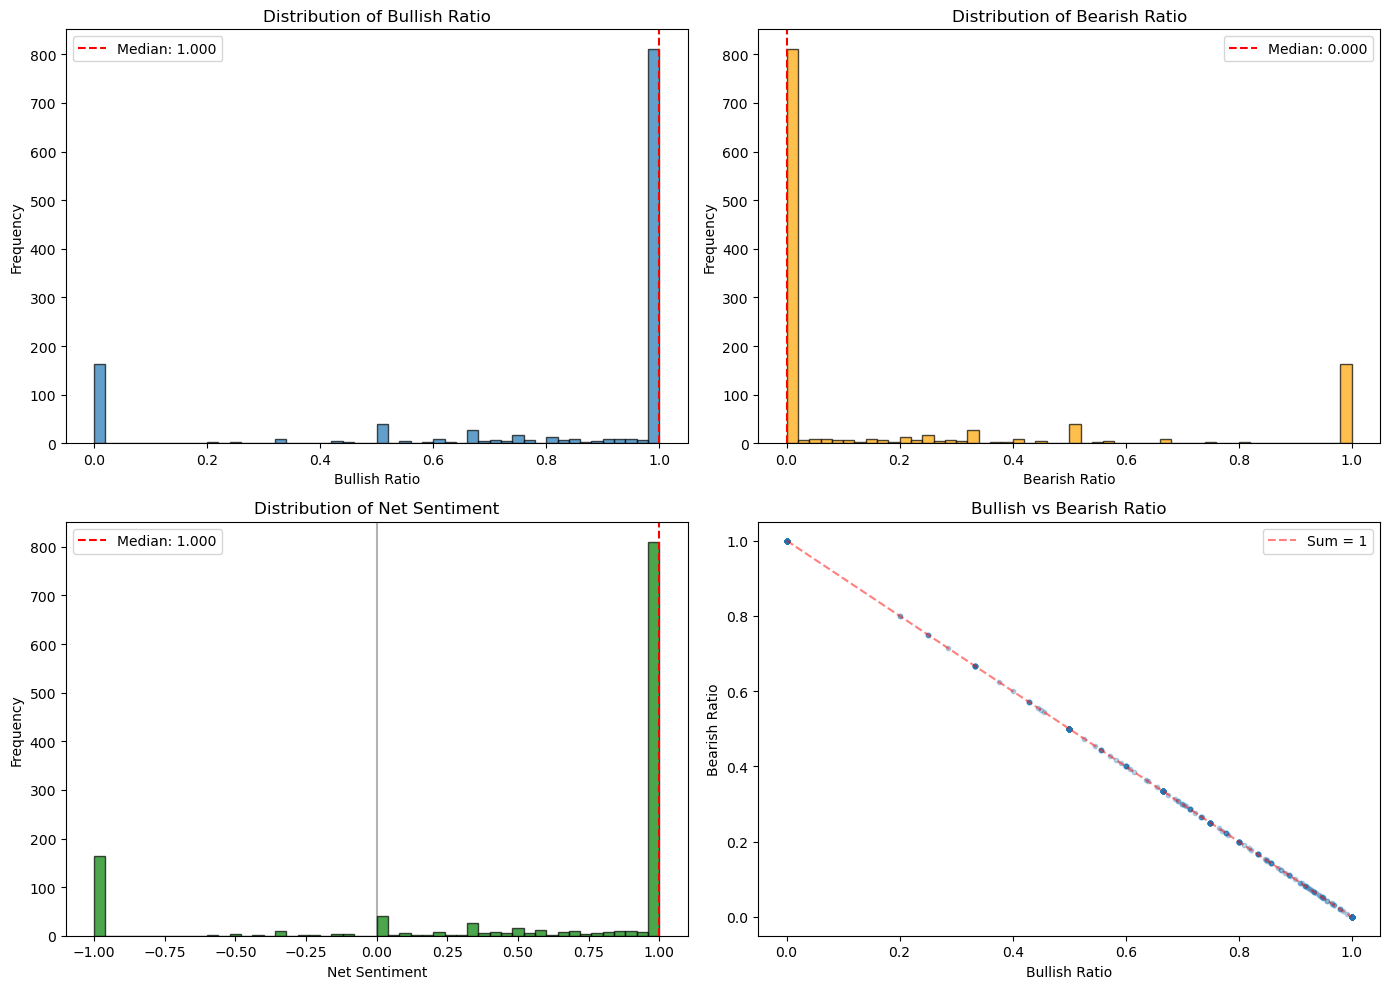


Validation Checks:
Bullish + Bearish ratio should ≈ 1.0:
  Mean sum: 1.000000
  Min sum: 1.000000
  Max sum: 1.000000

Net sentiment should be in [-1, 1]:
  Min: -1.000000
  Max: 1.000000

Overall sentiment bias:
  Mean bullish ratio: 0.804
  Mean bearish ratio: 0.196
  Mean net sentiment: 0.608


In [5]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter out NaN values for visualization
features_vis = features_sample.dropna(subset=['bullish_ratio', 'bearish_ratio', 'net_sentiment'])

# 1. Bullish Ratio distribution
axes[0, 0].hist(features_vis['bullish_ratio'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Bullish Ratio')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Bullish Ratio')
axes[0, 0].axvline(features_vis['bullish_ratio'].median(), color='red', 
                    linestyle='--', label=f"Median: {features_vis['bullish_ratio'].median():.3f}")
axes[0, 0].legend()

# 2. Bearish Ratio distribution
axes[0, 1].hist(features_vis['bearish_ratio'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Bearish Ratio')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Bearish Ratio')
axes[0, 1].axvline(features_vis['bearish_ratio'].median(), color='red', 
                    linestyle='--', label=f"Median: {features_vis['bearish_ratio'].median():.3f}")
axes[0, 1].legend()

# 3. Net Sentiment distribution
axes[1, 0].hist(features_vis['net_sentiment'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Net Sentiment')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Net Sentiment')
axes[1, 0].axvline(features_vis['net_sentiment'].median(), color='red', 
                    linestyle='--', label=f"Median: {features_vis['net_sentiment'].median():.3f}")
axes[1, 0].axvline(0, color='black', linestyle='-', alpha=0.3)
axes[1, 0].legend()

# 4. Bullish vs Bearish scatter
axes[1, 1].scatter(features_vis['bullish_ratio'], features_vis['bearish_ratio'], 
                   alpha=0.3, s=10)
axes[1, 1].set_xlabel('Bullish Ratio')
axes[1, 1].set_ylabel('Bearish Ratio')
axes[1, 1].set_title('Bullish vs Bearish Ratio')
axes[1, 1].plot([0, 1], [1, 0], 'r--', alpha=0.5, label='Sum = 1')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print validation checks
print(f"\nValidation Checks:")
print(f"="*60)
print(f"Bullish + Bearish ratio should ≈ 1.0:")
ratio_sum = features_vis['bullish_ratio'] + features_vis['bearish_ratio']
print(f"  Mean sum: {ratio_sum.mean():.6f}")
print(f"  Min sum: {ratio_sum.min():.6f}")
print(f"  Max sum: {ratio_sum.max():.6f}")

print(f"\nNet sentiment should be in [-1, 1]:")
print(f"  Min: {features_vis['net_sentiment'].min():.6f}")
print(f"  Max: {features_vis['net_sentiment'].max():.6f}")

print(f"\nOverall sentiment bias:")
print(f"  Mean bullish ratio: {features_vis['bullish_ratio'].mean():.3f}")
print(f"  Mean bearish ratio: {features_vis['bearish_ratio'].mean():.3f}")
print(f"  Mean net sentiment: {features_vis['net_sentiment'].mean():.3f}")

## 6. Process All Years

In [6]:
# Process all years and concatenate
all_features = []
processing_stats = []

print(f"{'='*60}")
print(f"Processing all years...")
print(f"{'='*60}\n")

for file in tqdm(files, desc="Processing years"):
    try:
        # Load year data
        year = file.split('_')[-1].replace('.csv', '')
        file_path = INPUT_FOLDER / file
        
        df_year = pd.read_csv(file_path)
        
        # Calculate features
        features_year = calculate_basic_sentiment_features(df_year)
        
        # Add to list
        all_features.append(features_year)
        
        # Track stats
        processing_stats.append({
            'year': year,
            'input_rows': len(df_year),
            'feature_rows': len(features_year),
            'unique_symbols': features_year['symbol'].nunique(),
            'unique_dates': features_year['date'].nunique()
        })
        
    except Exception as e:
        print(f"Error processing {file}: {str(e)}")

# Concatenate all years
features_all = pd.concat(all_features, ignore_index=True)

print(f"\n{'='*60}")
print(f"Processing Complete!")
print(f"{'='*60}")
print(f"\nTotal features: {len(features_all):,}")
print(f"Unique symbols: {features_all['symbol'].nunique():,}")
print(f"Date range: {features_all['date'].min()} to {features_all['date'].max()}")

# Show processing stats
df_stats = pd.DataFrame(processing_stats)
print(f"\nProcessing Statistics by Year:")
display(df_stats)

Processing all years...



Processing years:   0%|          | 0/15 [00:00<?, ?it/s]


Processing Complete!

Total features: 3,505,817
Unique symbols: 8,245
Date range: 2010-06-02 00:00:00 to 2024-01-03 00:00:00

Processing Statistics by Year:


,year,input_rows,feature_rows,unique_symbols,unique_dates
0,2010,11824,8718,1698,147
1,2011,34180,24482,2536,252
2,2012,80848,32152,2557,250
3,2013,463112,105570,3328,252
4,2014,1182579,155934,3630,252
5,2015,1635280,204077,3876,252
6,2016,2349348,241359,3922,252
7,2017,5109376,297821,3916,251
8,2018,5999550,321499,3960,251
9,2019,5994560,327605,3992,252


## 7. Final Data Inspection

In [7]:
# Inspect final dataset
print(f"Final Features Dataset:")
print(f"="*60)
print(f"Shape: {features_all.shape}")
print(f"\nColumns: {list(features_all.columns)}")
print(f"\nData types:")
print(features_all.dtypes)
print(f"\nMemory usage: {features_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nNull values:")
print(features_all.isnull().sum())
print(f"\nSample data:")
display(features_all.head(20))
print(f"\nSummary statistics:")
display(features_all[['n_bullish', 'n_bearish', 'total_labeled', 
                       'bullish_ratio', 'bearish_ratio', 'net_sentiment']].describe())

Final Features Dataset:
Shape: (3505817, 8)

Columns: ['symbol', 'date', 'n_bullish', 'n_bearish', 'total_labeled', 'bullish_ratio', 'bearish_ratio', 'net_sentiment']

Data types:
sentiment
symbol                   object
date             datetime64[ns]
n_bullish                 int64
n_bearish                 int64
total_labeled             int64
bullish_ratio           float64
bearish_ratio           float64
net_sentiment           float64
dtype: object

Memory usage: 389.72 MB

Null values:
sentiment
symbol           0
date             0
n_bullish        0
n_bearish        0
total_labeled    0
bullish_ratio    0
bearish_ratio    0
net_sentiment    0
dtype: int64

Sample data:


sentiment,symbol,date,n_bullish,n_bearish,total_labeled,bullish_ratio,bearish_ratio,net_sentiment
0,A,2010-12-01,1,0,1,1.0,0.0,1.0
1,A,2010-12-16,1,0,1,1.0,0.0,1.0
2,A,2010-12-27,1,0,1,1.0,0.0,1.0
3,AA,2010-08-23,0,1,1,0.0,1.0,-1.0
4,AA,2010-08-24,0,1,1,0.0,1.0,-1.0
5,AA,2010-08-31,0,1,1,0.0,1.0,-1.0
6,AA,2010-09-07,1,0,1,1.0,0.0,1.0
7,AA,2010-09-16,1,0,1,1.0,0.0,1.0
8,AA,2010-09-21,1,0,1,1.0,0.0,1.0
9,AA,2010-09-22,2,0,2,1.0,0.0,1.0



Summary statistics:


sentiment,n_bullish,n_bearish,total_labeled,bullish_ratio,bearish_ratio,net_sentiment
count,3.505817e+06,3.505817e+06,3.505817e+06,3.505817e+06,3.505817e+06,3.505817e+06
mean,2.111279e+01,3.261176e+00,2.437397e+01,8.449449e-01,1.550551e-01,6.898898e-01
std,2.547006e+02,3.979901e+01,2.767643e+02,2.986041e-01,2.986041e-01,5.972081e-01
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00,8.461538e-01,0.000000e+00,6.923077e-01
50%,2.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
75%,6.000000e+00,1.000000e+00,7.000000e+00,1.000000e+00,1.538462e-01,1.000000e+00
max,9.182600e+04,2.796000e+04,9.835800e+04,1.000000e+00,1.000000e+00,1.000000e+00


## 8. Save to Pickle

In [8]:
# Save features to pickle
print(f"Saving features to: {OUTPUT_FILE}")
features_all.to_pickle(OUTPUT_FILE)
print(f"✓ Saved successfully!")

# Verify save
print(f"\nVerifying saved file...")
features_loaded = pd.read_pickle(OUTPUT_FILE)
print(f"✓ File readable")
print(f"✓ Shape matches: {features_loaded.shape == features_all.shape}")
print(f"✓ Columns match: {list(features_loaded.columns) == list(features_all.columns)}")

# File size
file_size_mb = OUTPUT_FILE.stat().st_size / 1024**2
print(f"\nFile size: {file_size_mb:.2f} MB")

Saving features to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd\features_01_basic_sentiment.pkl
✓ Saved successfully!

Verifying saved file...
✓ File readable
✓ Shape matches: True
✓ Columns match: True

File size: 204.03 MB


## Summary

✓ **Features Calculated:**
- Bullish Ratio
- Bearish Ratio  
- Net Sentiment

✓ **Output:** `features_01_basic_sentiment.pkl`

✓ **Ready for:** Feature aggregation in final pipeline